# Step 16 — heatmap: does a child keep their endotype from visit to visit?

**Data type: RNA_array** (GSE65391). **Reads:** `step13_site_{A,B,C}.rds`.
**Writes:** `figures/fig16_RNA_array_endotype_across_visits_{A,B,C}.png`.

At each site: one row per child with SLE, one column per visit in order (first, second, …). Left panel,
the endotype at that visit; middle, the stage; right, the interferon score. Grey means the child had no
visit with that number. Rows are grouped by the endotype at the first visit and ordered within each
group by how often the child stays in it.

The coordinator receives per-site counts only: children who never change endotype, and transitions
between consecutive visits, split by whether SLEDAI rose, fell or stayed the same.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
source("../src/figures.R")
start_log("16")
K <- readRDS(art("step13_model.rds"))$k
EN_COL <- endotype_colours(paste0("E", seq_len(K)))

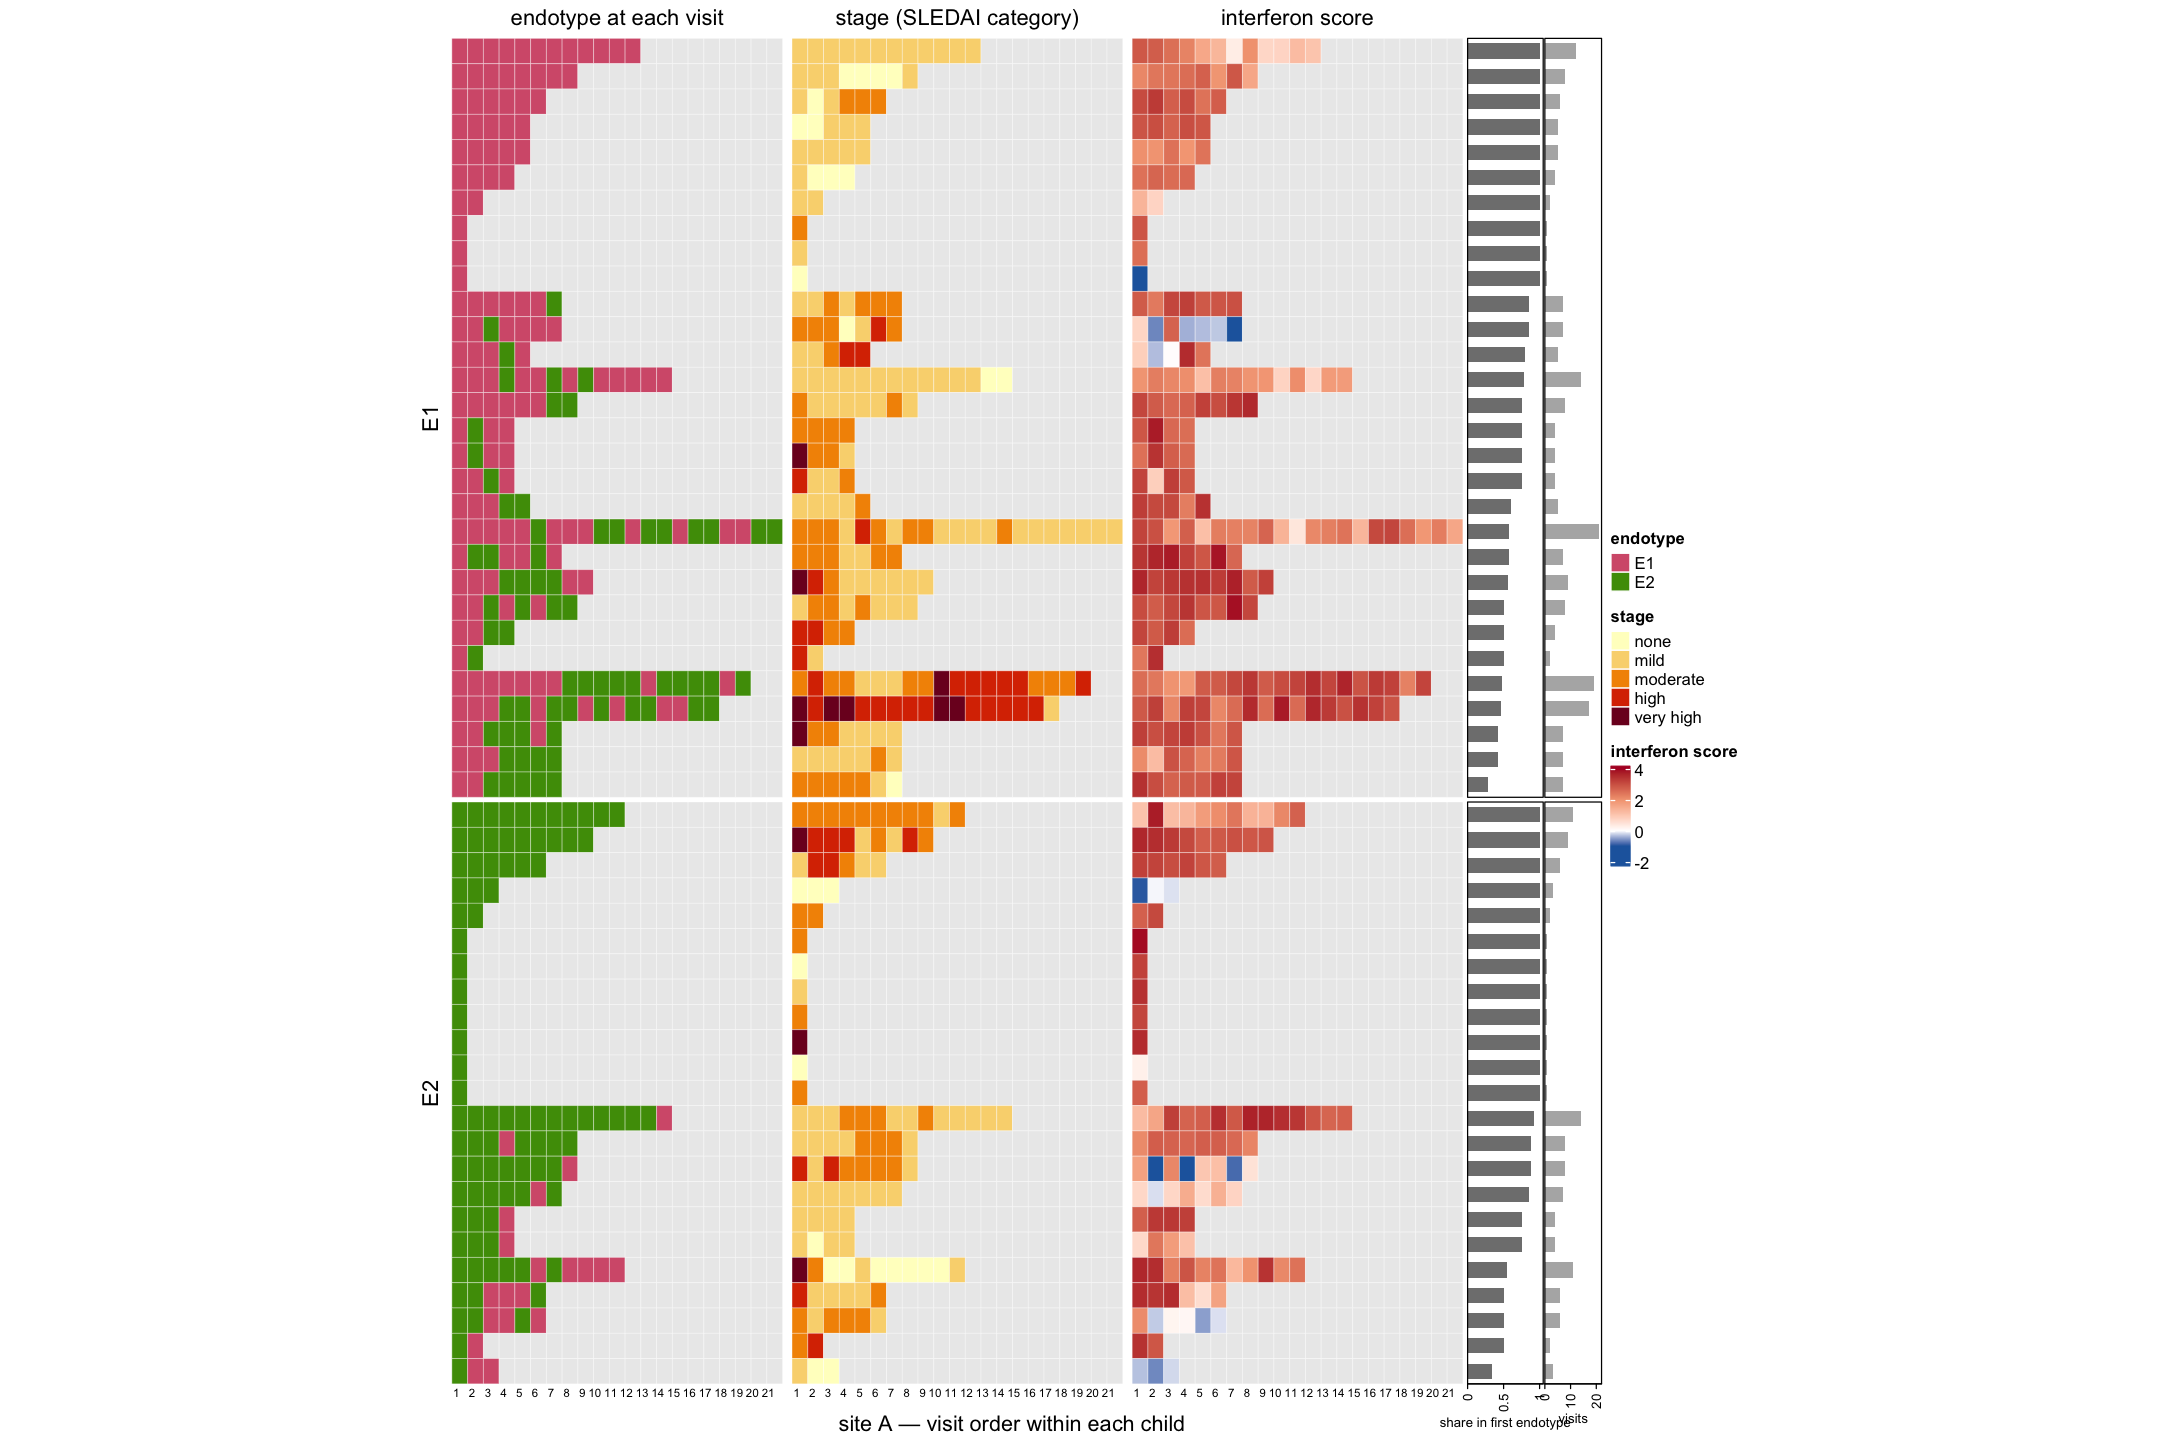

In [2]:
visit_figure <- function(s) {
  m <- readRDS(site_file("13", s))$meta
  m <- m[m$disease == "SLE", ]
  m$visit_rank <- ave(m$visit, m$subject, FUN = function(v) rank(v, ties.method = "first"))
  pts <- unique(m$subject); nv <- max(m$visit_rank)
  grid_of <- function(v) { g <- matrix(NA, length(pts), nv, dimnames = list(pts, seq_len(nv)))
                           g[cbind(match(m$subject, pts), m$visit_rank)] <- v; g }
  G_en <- grid_of(as.character(m$endotype)); G_st <- grid_of(as.character(m$stage)); G_if <- grid_of(m$ifn_score)
  base   <- factor(G_en[, 1], levels = names(EN_COL))
  stay   <- rowMeans(G_en == G_en[, 1], na.rm = TRUE)
  visits <- rowSums(!is.na(G_en))
  ord <- order(base, -stay, -visits)
  ra <- rowAnnotation("share in first endotype" = anno_barplot(stay[ord], width = unit(16, "mm"), gp = gpar(fill = "grey50", col = NA)),
                      visits = anno_barplot(visits[ord], width = unit(12, "mm"), gp = gpar(fill = "grey70", col = NA)),
                      annotation_name_gp = gpar(fontsize = 8))
  h1 <- Heatmap(G_en[ord, ], name = "endotype", col = EN_COL, na_col = "grey92", row_split = base[ord],
                cluster_rows = FALSE, cluster_columns = FALSE, show_row_names = FALSE,
                column_names_gp = gpar(fontsize = 7), column_names_rot = 0, column_title = "endotype at each visit",
                rect_gp = gpar(col = "white", lwd = 0.3), width = unit(70, "mm"))
  h2 <- Heatmap(G_st[ord, ], name = "stage", col = STAGE_COL, na_col = "grey92", cluster_rows = FALSE,
                cluster_columns = FALSE, show_row_names = FALSE, column_names_gp = gpar(fontsize = 7),
                column_names_rot = 0, column_title = "stage (SLEDAI category)", rect_gp = gpar(col = "white", lwd = 0.3),
                heatmap_legend_param = list(at = names(STAGE_COL)), width = unit(70, "mm"))
  h3 <- Heatmap(G_if[ord, ], name = "interferon score", col = IFN_COL, na_col = "grey92", cluster_rows = FALSE,
                cluster_columns = FALSE, show_row_names = FALSE, column_names_gp = gpar(fontsize = 7),
                column_names_rot = 0, column_title = "interferon score", rect_gp = gpar(col = "white", lwd = 0.3),
                right_annotation = ra, width = unit(70, "mm"))
  # what the site sends: counts only
  m <- m[order(m$subject, m$visit_rank), ]
  tr <- do.call(rbind, lapply(split(m, m$subject), function(p) if (nrow(p) < 2) NULL else
          data.frame(move = paste(p$endotype[-nrow(p)], "->", p$endotype[-1]),
                     sledai = factor(sign(diff(p$sledai)), levels = c(-1, 0, 1), labels = c("fell", "same", "rose")))))
  msg <- send(list(children = length(pts), two_or_more = sum(visits >= 2),
                   never_change = sum(stay == 1 & visits >= 2),
                   transitions = table(tr$move, tr$sledai)), s, "visit-stability counts", length(pts))
  list(ht = h1 + h2 + h3, msg = msg)
}
out <- lapply(setNames(SITES, SITES), visit_figure)
for (s in SITES) {
  png(fig("fig16_RNA_array_endotype_across_visits_%s.png", s), width = 2800, height = 2000, res = 170)
  draw(out[[s]]$ht, column_title = sprintf("site %s — visit order within each child", s),
       column_title_side = "bottom", merge_legend = TRUE)
  invisible(dev.off())
}
options(repr.plot.width = 18, repr.plot.height = 12)
draw(out$A$ht, column_title = "site A — visit order within each child", column_title_side = "bottom", merge_legend = TRUE)

Sites B and C are in `figures/fig16_RNA_array_endotype_across_visits_B.png` and `..._C.png`.

## Pooled counts

In [3]:
msgs <- lapply(out, `[[`, "msg")
c(children = sum(sapply(msgs, `[[`, "children")),
  with_two_or_more_visits = sum(sapply(msgs, `[[`, "two_or_more")),
  of_whom_never_change = sum(sapply(msgs, `[[`, "never_change")))
Reduce(`+`, lapply(msgs, `[[`, "transitions"))

children with_two_or_more_visits    of_whom_never_change 
                    158                     131                      42

          
           fell same rose
  E1 -> E1   85  122   68
  E1 -> E2   38   44   30
  E2 -> E1   33   48   31
  E2 -> E2  113   90   64

## Findings

Endotype is only partly stable. Of 131 children with two or more visits, 42 (32%) keep the same
endotype at every visit. Moves between endotypes do not follow SLEDAI in a simple way: a move from E1
to E2 comes with a rising score about as often as with a falling one. E1 and E2 look like two states
of blood composition that a child moves between, rather than two fixed kinds of patient.